# Compact
Load Compact CSV files and create a DataFrame named `df`.

In [1]:
from pathlib import Path
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Compact"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()
df_clean = df.copy()

print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")
df_clean.head()

Loaded 2045 rows from 214 file(s) in /Users/gretawette/Documents/Thesis/data/raw/Alternative Medien/Compact


,Date,Title,Inhalt,URL,source,source_file
0,2025-06-11,COMPACT gegen Regierung: So war der 2. Tag!,Der zweite und letzte Verhandlungstag im COMPA...,https://www.compact-online.de/compact-gegen-re...,Compact,Compact_2025-06-11_raw.csv
1,2025-06-11,COMPACT-Verbot 2024: Der Film,Als Nancy Faeser eskalierte. Die denkwürdigste...,https://www.compact-online.de/compact-verbot-2...,Compact,Compact_2025-06-11_raw.csv
2,2025-06-11,Drogen und Rituale: Mysteriöse Inka-Stätte ent...,Ein neuer Fund in den peruanischen Anden eröff...,https://www.compact-online.de/drogen-und-ritua...,Compact,Compact_2025-06-11_raw.csv
3,2025-06-11,Trumps Einsatz in Los Angeles: Ein Medientrauma,Das Durchgreifen des US-Präsidenten gegen das ...,https://www.compact-online.de/trumps-einsatz-i...,Compact,Compact_2025-06-11_raw.csv
4,2025-06-11,Verrat an BismarckCOMPACT+,Essay von Rolf Hochhut. Deutschland hat seinen...,https://www.compact-online.de/verrat-an-bismarck/,Compact,Compact_2025-06-11_raw.csv


In [2]:
# compute and display missing values per column for the cleaned dataframe
missing = df_clean.isna().sum().rename("missing_count").to_frame()
missing["missing_pct"] = (missing["missing_count"] / len(df_clean)) * 100
missing = missing.sort_values("missing_count", ascending=False)
missing

,missing_count,missing_pct
Date,0,0.0
Title,0,0.0
Inhalt,0,0.0
URL,0,0.0
source,0,0.0
source_file,0,0.0


In [3]:
# filter timeframe Aug 2025 through Jan 2026 (inclusive) and keep as df_clean
start, end = "2025-08-01", "2026-01-31"

dates = pd.to_datetime(df_clean["Date"], errors="coerce")
mask = (dates >= pd.Timestamp(start)) & (dates <= pd.Timestamp(end))

df_clean = df_clean.loc[mask].copy()
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")

print(f"Rows in selected period: {len(df_clean)}")
df_clean.sort_values("Date").head()

Rows in selected period: 1614


,Date,Title,Inhalt,URL,source,source_file
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial...",https://www.compact-online.de/blond-linker-has...,Compact,Compact_2025-08-01_raw.csv
345,2025-08-01,Die Macht der Israel-Lobby in den USA,Die beinharte Unterstützung Donald Trumps für ...,https://www.compact-online.de/die-macht-der-is...,Compact,Compact_2025-08-01_raw.csv
346,2025-08-01,Ein Polizist aus dem Volk,Karsten Hilse im Porträt. Ein Menetekel: Am Ta...,https://www.compact-online.de/ein-polizist-aus...,Compact,Compact_2025-08-01_raw.csv
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gers...,Die Bundesregierung möchte die politischer Som...,https://www.compact-online.de/spd-politiker-fo...,Compact,Compact_2025-08-01_raw.csv
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: T...",https://www.compact-online.de/die-grosse-vertu...,Compact,Compact_2025-08-01_raw.csv


Date filter

In [4]:
df_clean['Date'].min(), df_clean['Date'].max()

(Timestamp('2025-08-01 00:00:00'), Timestamp('2026-01-31 00:00:00'))

In [5]:
# keep only the requested columns
_keep = ["Date", "Title", "Inhalt", "URL"]

if 'df_clean' in globals():
    df_clean = df_clean.loc[:, _keep].copy()

if 'df_aug2025_jan2026' in globals():
    df_aug2025_jan2026 = df_aug2025_jan2026.loc[:, _keep].copy()

if 'df' in globals():
    df = df.loc[:, _keep].copy()

# show result
df_clean.head()

,Date,Title,Inhalt,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial...",https://www.compact-online.de/blond-linker-has...
345,2025-08-01,Die Macht der Israel-Lobby in den USA,Die beinharte Unterstützung Donald Trumps für ...,https://www.compact-online.de/die-macht-der-is...
346,2025-08-01,Ein Polizist aus dem Volk,Karsten Hilse im Porträt. Ein Menetekel: Am Ta...,https://www.compact-online.de/ein-polizist-aus...
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gers...,Die Bundesregierung möchte die politischer Som...,https://www.compact-online.de/spd-politiker-fo...
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: T...",https://www.compact-online.de/die-grosse-vertu...


In [6]:
from IPython.display import display
display(df_clean.head(3))

,Date,Title,Inhalt,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial...",https://www.compact-online.de/blond-linker-has...
345,2025-08-01,Die Macht der Israel-Lobby in den USA,Die beinharte Unterstützung Donald Trumps für ...,https://www.compact-online.de/die-macht-der-is...
346,2025-08-01,Ein Polizist aus dem Volk,Karsten Hilse im Porträt. Ein Menetekel: Am Ta...,https://www.compact-online.de/ein-polizist-aus...


Removal of "Mehr zum Thema"

In [7]:
import re
def remove_mehr_zum_thema(text):
    if pd.isna(text):
        return text
    
    # Remove everything from "Mehr zum Thema" until end
    cleaned = re.sub(r"\n*\s*Mehr zum Thema.*$", "", text, flags=re.DOTALL)
    return cleaned.strip()

df_clean["Inhalt"] = df_clean["Inhalt"].apply(remove_mehr_zum_thema)

In [8]:
df_clean.head()

,Date,Title,Inhalt,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial...",https://www.compact-online.de/blond-linker-has...
345,2025-08-01,Die Macht der Israel-Lobby in den USA,Die beinharte Unterstützung Donald Trumps für ...,https://www.compact-online.de/die-macht-der-is...
346,2025-08-01,Ein Polizist aus dem Volk,Karsten Hilse im Porträt. Ein Menetekel: Am Ta...,https://www.compact-online.de/ein-polizist-aus...
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gers...,Die Bundesregierung möchte die politischer Som...,https://www.compact-online.de/spd-politiker-fo...
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: T...",https://www.compact-online.de/die-grosse-vertu...


In [9]:
# rename column "Inhalt" to "Text"
if "Inhalt" in df_clean.columns:
    df_clean = df_clean.rename(columns={"Inhalt": "Text"})

df_clean.head()

,Date,Title,Text,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial...",https://www.compact-online.de/blond-linker-has...
345,2025-08-01,Die Macht der Israel-Lobby in den USA,Die beinharte Unterstützung Donald Trumps für ...,https://www.compact-online.de/die-macht-der-is...
346,2025-08-01,Ein Polizist aus dem Volk,Karsten Hilse im Porträt. Ein Menetekel: Am Ta...,https://www.compact-online.de/ein-polizist-aus...
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gers...,Die Bundesregierung möchte die politischer Som...,https://www.compact-online.de/spd-politiker-fo...
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: T...",https://www.compact-online.de/die-grosse-vertu...


Duplicates

In [10]:
# Columns to check for duplicate records
dup_cols = ["Title"]

# Find duplicates (all rows that belong to duplicate groups)
dup_mask = df_clean.duplicated(subset=dup_cols, keep=False)
dups = df_clean.loc[dup_mask].sort_values(dup_cols)

print(f"Number of duplicate rows (across {dup_cols}): {len(dups)}")

# optional preview
dups.head()

Number of duplicate rows (across ['Title']): 75


,Date,Title,Text,URL
1015,2025-10-20,15 Jahre COMPACT: Die Jubiläums-Gala,Am 31. Januar 2026 feiern wir in Magdeburg den...,https://www.compact-online.de/15-jahre-compact...
1114,2025-10-29,15 Jahre COMPACT: Die Jubiläums-Gala,Am 31. Januar 2026 feiern wir in Magdeburg den...,https://www.compact-online.de/15-jahre-compact...
1193,2025-11-09,15 Jahre COMPACT: Die Jubiläums-Gala,Am 31. Januar 2026 feiern wir in Magdeburg den...,https://www.compact-online.de/15-jahre-compact...
795,2025-09-28,5 vor 12: Beginnt nächste Woche Krieg?,Achtung Kriegsgefahr! Während europäische Länd...,https://www.compact-online.de/5-vor-12-beginnt...
786,2025-09-27,5 vor 12: Beginnt nächste Woche Krieg?,Achtung Kriegsgefahr! Während europäische Länd...,https://www.compact-online.de/5-vor-12-beginnt...


In [11]:
# remove duplicates if either Title OR Inhalt is duplicated
dup_title = df_clean.duplicated(subset=["Title"], keep="first")
dup_text = df_clean.duplicated(subset=["Text"], keep="first")
dup_any = dup_title | dup_text

dups = df_clean.loc[dup_any].copy()      # removed duplicate rows
df_clean = df_clean.loc[~dup_any].copy() # keep only unique rows

print(f"Removed duplicates: {dup_any.sum()}")
print(f"Remaining rows: {len(df_clean)}")

df_clean.head()

Removed duplicates: 50
Remaining rows: 1564


,Date,Title,Text,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial...",https://www.compact-online.de/blond-linker-has...
345,2025-08-01,Die Macht der Israel-Lobby in den USA,Die beinharte Unterstützung Donald Trumps für ...,https://www.compact-online.de/die-macht-der-is...
346,2025-08-01,Ein Polizist aus dem Volk,Karsten Hilse im Porträt. Ein Menetekel: Am Ta...,https://www.compact-online.de/ein-polizist-aus...
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gers...,Die Bundesregierung möchte die politischer Som...,https://www.compact-online.de/spd-politiker-fo...
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: T...",https://www.compact-online.de/die-grosse-vertu...


In [12]:
compact_clean = df_clean.copy()
compact_clean["source"] = "Compact"
compact_clean = compact_clean[["Date", "Title", "Text", "source"]].copy()
compact_clean.to_csv("compact_clean.csv", index=False, encoding="utf-8")

## EDA

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

eda_df = df_clean.copy() if "df_clean" in globals() else df.copy()
eda_df["Date"] = pd.to_datetime(eda_df["Date"], errors="coerce")

text_col = "Text"
eda_df[text_col] = eda_df[text_col].astype("string")
eda_df = eda_df.dropna(subset=["Date", text_col]).copy()

print(f"Rows used for EDA: {len(eda_df):,}")

Rows used for EDA: 1,564


In [14]:
eda_df["article_length_words"] = eda_df[text_col].str.split().str.len()
eda_df["article_length_chars"] = eda_df[text_col].str.len()

eda_df["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)

count    1564.0
mean      495.4
std       484.3
min        23.0
10%        69.0
25%       118.0
50%       420.5
75%       668.8
90%      1111.5
95%      1483.8
99%      2218.8
max      4324.0
Name: article_length_words, dtype: float64

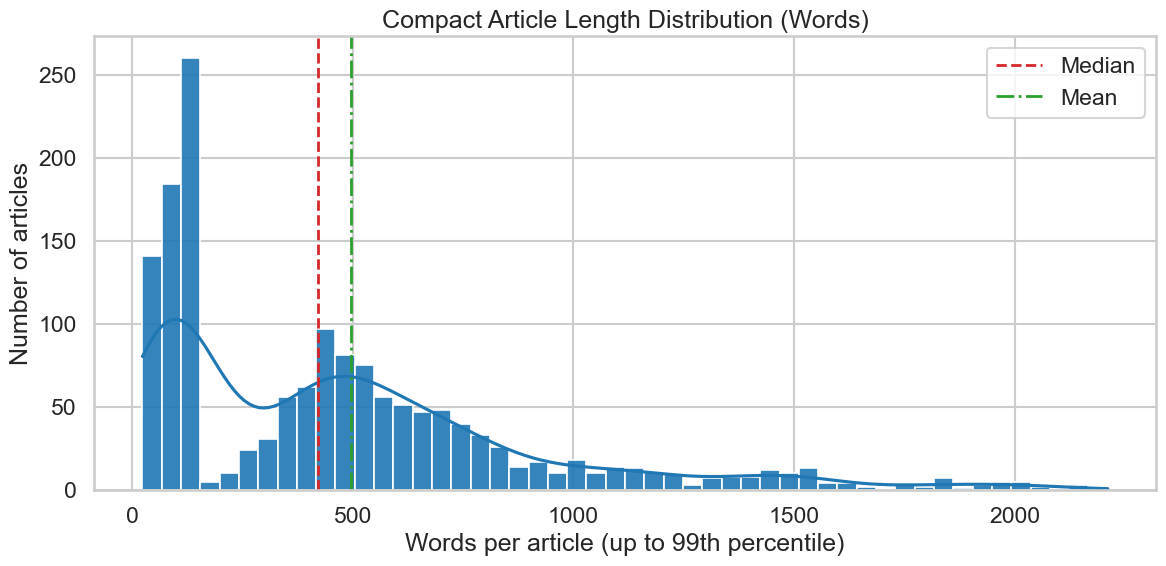

In [15]:
q99 = eda_df["article_length_words"].quantile(0.99)
length_plot = eda_df[eda_df["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(eda_df["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(eda_df["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("Compact Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Inspect 20 shortest articles by word count
df_inspect = eda_df if "eda_df" in globals() else df_clean.copy()

if "article_length_words" not in df_inspect.columns:
    df_inspect["article_length_words"] = df_inspect["Text"].astype("string").str.split().str.len()

# ensure source column exists (most data is from SOURCE_NAME == "Compact")
if "source" not in df_inspect.columns:
    df_inspect["source"] = SOURCE_NAME if "SOURCE_NAME" in globals() else "Compact"

# build result (Title, text, source, word_count) sorted ascending
shortest = (
    df_inspect.sort_values("article_length_words", ascending=True)
    .loc[:, ["Title", "Text", "source", "article_length_words"]]
    .head(20)
    .rename(columns={"Text": "text", "article_length_words": "word_count"})
)

# allow longer text columns to be displayed
pd.options.display.max_colwidth = 1000

display(shortest)

,Title,text,source,word_count
632,Macron am Boden: Live beim Aufstand!,Frankreich im Ausnahmezustand – COMPACT ist live vor Ort dabei! COMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,Compact,23
594,Albaner (18) sticht auf Lehrerin ein! NOT-OP!,Amoklauf in Essener Schule. SEK muss schießen. Dr. Stephanie Elsässer klärt auf! COMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,Compact,25
646,MOSSAD und 9/11,Heute vor 24 Jahren: Israelische Geheimdienstler wurden nach den Anschlägen des 11. September 2001 vom FBI festgenommen und zwei Monate eingesperrt. Waren sie in das Terrorkomplott verwickelt?,Compact,27
464,„Remigration!“: Söder-Interview wird abgebrochen!,Aufregung am Bundestag! Das Sommer-Interview der ARD mit CSU-Chef Söder muss abgebrochen werden. Wir sind vor Ort! COMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,Compact,30
1187,Halle (Saale): Antifa brüllt gegen Buchmesse,"Wirbel um die «Seitenwechsel»-Buchmesse in Halle (Saale). Sehen Sie hier brüllende Antifas, spannende Interviews und Impressionen von unserem Messestand! COMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",Compact,32
1388,AfD-Jugend: COMPACT beim Kampf um Gießen!,"Ausnahmezustand in Gießen: Tausende Antifa wollen den Gründungskongress der AfD-Jugend stürmen! Blockaden, Wasserwerfer, Angriffe auf Polizisten und Teilnehmer. COMPACT mittendrin! COMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",Compact,33
1901,Vor Ort: Orban geht gegen Hammerbande vor!,"In Budapest strebt der Prozess gegen Hammerbanden-„Maja“ seinem Höhepunkt entgegen. Unser Korrespondent Sebastian Schmidtke ist dabei und dokumentiert, wie deutsche Politiker vor Ort Stimmung machen. Die Reportage sehen Sie in dem Video oben.",Compact,33
1575,Gefahr Migration: Ex-Islamist packt aus!,Irfan Peci war Propaganda-Chef der deutschen al-Qaida! Inzwischen hat er zum christlichen Glauben gefunden und warnt vor den schrecklichen Folgen der Massenmigration. Was steht Deutschland bevor? Unsere heutige Shop-Empfehlung: „COMPACT-Spezial 45: Mädchen. Messer. Morde“,Compact,34
1656,Rückblick: Unsere größten TV-Highlights!,Nur noch wenige Stunden… – 2025 war ein spektakuläres Jahr mit vielen Höhen und Tiefen. In unserem COMPACT-Rückblick sehen Sie die wichtigsten Ereignisse in einer kurzweiligen Zusammenfassung. Wir wünschen einen frohen Jahreswechsel und ein gesundes Neues!,Compact,36
1692,Spreewald: Wird SIE die erste AfD-Landrätin?,Widerstand im Gurkenland: Der Kreis Oberspreewald-Lausitz gilt als AfD-Hochburg. In wenigen Tagen wird hier ein neuer Landrat gewählt. Die blaue Kandidatin hat gute Chancen. Paul Klemm hat sie mit der Kamera begleitet. Unsere heutige Produktempfehlung: Silbermedaille Höcke-Taler,Compact,37


--> This indicates two types of documents in the corpus: News briefs / ticker posts and Normal articles

NameError: name 'daily_counts' is not defined

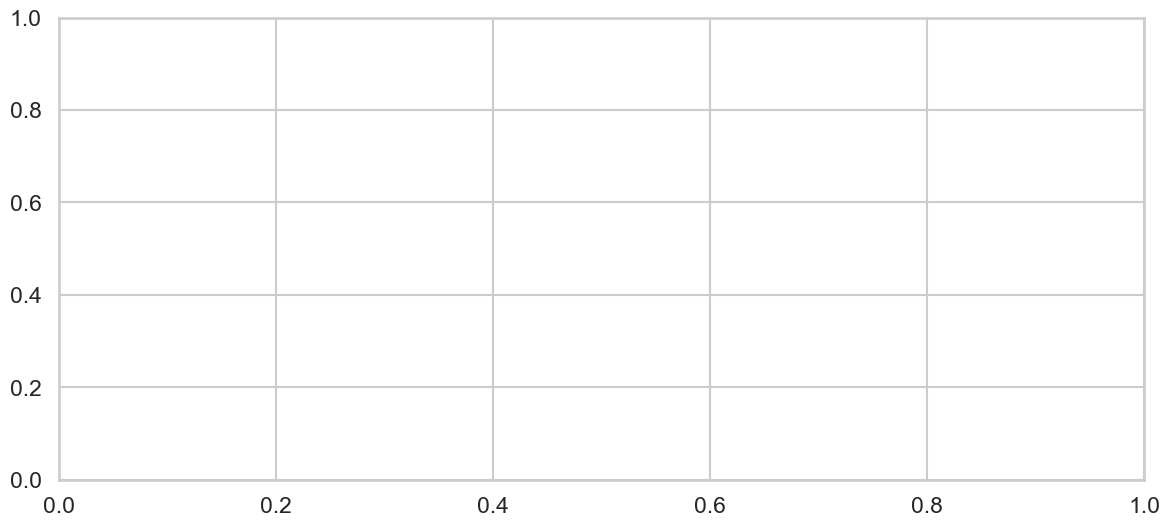

In [17]:
# fig, ax = plt.subplots(figsize=(14, 6))
# ax.bar(
#     daily_counts["Date"],
#     daily_counts["articles"],
#     color="#9ecae1",
#     alpha=0.8,
#     width=1.0,
#     label="Daily articles",
# )
# ax.plot(
#     daily_counts["Date"],
#     daily_counts["rolling_7d"],
#     color="#08519c",
#     linewidth=2.5,
#     label="7-day average",
# )

# ax.set_title("Compact Articles Per Day")
# ax.set_xlabel("Date")
# ax.set_ylabel("Number of articles")
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.legend(frameon=True)
# plt.tight_layout()
# plt.show()

In [9]:
compact_clean = df_clean.copy()

if "Inhalt" in compact_clean.columns:
    compact_clean = compact_clean.rename(columns={"Inhalt": "Text"})

compact_clean["source"] = "Compact"
compact_clean = compact_clean[["Date", "Title", "Text", "source"]].copy()
compact_clean.to_csv("compact_clean.csv", index=False, encoding="utf-8")

## BERTopic

In [18]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "data preprocessing":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [21]:
from BERTopic.bertopic_pipeline import run_bertopic_pipeline

In [22]:
from BERTopic.bertopic_config import BERTopicConfig
print(BERTopicConfig().min_df, BERTopicConfig().max_df)

2 0.9


In [23]:
from pathlib import Path
import sys

# from ".../data preprocessing" -> project root ".../Thesis"
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("cwd:", Path.cwd())
print("project root added:", PROJECT_ROOT)

cwd: /Users/gretawette/Documents/Thesis/data preprocessing
project root added: /Users/gretawette/Documents/Thesis


In [24]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(),
    id_col="URL",
    source_name="Compact",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-09 20:02:25,732 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/49 [00:00<?, ?it/s]

2026-03-09 20:02:39,917 - BERTopic - Embedding - Completed ✓
2026-03-09 20:02:39,919 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 20:02:46,639 - BERTopic - Dimensionality - Completed ✓
2026-03-09 20:02:46,639 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 20:02:46,675 - BERTopic - Cluster - Completed ✓
2026-03-09 20:02:46,680 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 20:02:47,382 - BERTopic - Representation - Completed ✓


In [25]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,0,1396,0_afd_russland_cdu_merz,"[afd, russland, cdu, merz, ausgabe, partei, ukraine, spd, putin, eu]","[Die AfD befindet sich, besonders befeuert durch das Versagen von Merz und der Bundesregierung, im Höhenflug. Das gilt damit auch für die COMPACT-Kanzlermünze Alice Weidel, die nicht nur als Wertanlage an Bedeutung gewinnt, sondern auch an Aktualität. Hier mehr erfahren. Die politische Landschaft in Deutschland wird weiter kräftig durcheinanderwirbelt. Denn die Bundesbürger haben die Faxen dicke. Laut aktueller Umfrage des Meinungsforschungsinstituts Insa bauen die Blauen Vorsprung gegenüber der CDU/CSU weiter aus und erreichen jetzt mit 27 Prozent ihren bisher höchsten bundesweit gemessenen Wert. „AfD stärkste politische Kraft“ Die Union hingegen fällt auf 24,5 Prozent zurück, womit der Abstand zwischen beiden Parteien nun bei zweieinhalb Prozentpunkten liegt. Insa-Chef Hermann Binkert klipp und klar: „Die AfD ist derzeit die stärkste politische Kraft.“ Dieser Aufstieg wird insbesondere durch das Versagen der Bundesregierung unter der schwarz-roten Koalition sowie der eklatanten S..."
1,1,83,1_stress_körper_zellen_herz,"[stress, körper, zellen, herz, gehirn, ernährung, studien, mangel, omega, radikale]","[Je fitter unser Herz, desto agiler und gesünder auch das Gehirn. Studien zeigen starke Wechselwirkung zwischen Herz und Gehirn.* Dass Herz und Gehirn auf besondere Weise miteinander kommunizieren, weiß man bereits. Manche Wissenschaftler schreiben dem Herzen sogar die Fähigkeit zu, sogar ein kleines Gehirn zu haben – das Herz-Gehirn. Dass es einen starken Zusammenhang zwischen unserem „großen“ Gehirn und der Herzgesundheit gibt, zeigte unlängst eine US-amerikanische Studie. Ein Gehirn bleibt während des Alterns fit, wenn nur das Herz in optimaler Verfassung sei. So das Ergebnis besagter Studie aus den USA. Bei Menschen, wo der Blutfluss durch eine beeinträchtigte Herzfunktion eingeschränkt ist, altere auch das Gehirn schneller und zwar um ca. zwei Jahre. Das Fatale, ein schwaches Herz kann man auch ohne Symptome haben. An der Studie nahmen nämlich auch jüngere Menschen teil, die keinerlei Anzeichen von Herzproblemen zeigten. Auch bei Ihnen gab es Personen die eine unterdurchschnit..."
2,2,56,2_silber_dollar_silbermedaillen_medaillen,"[silber, dollar, silbermedaillen, medaillen, edelmetalle, putin, 2026, silberpreis, edelmetall, unze]","[Neues Allzeithoch: Silber gewinnt immer schneller, noch schneller als Gold. Der Grund: Die Vorräte an physischem Silber werden leerverkauft! Sichern Sie sich Silber, solange es noch geht – mit den begehrten COMPACT-Medaillen aus Silber in der höchsten Reinheitsstufe. Neues Allzeithoch bei Silber: Am Donnerstand mit 50,14 Euro pro Feinunze, gestern dann nochmal 50,10 Euro. Damit wurde der bisherige Höchststand vom 28.11. übertroffen. Innerhalb eines Jahres stieg der Silberpreis um 80 Prozent (in Euro) oder knapp 100 Prozent (in Dollar), was schon gewaltig ist. Aber die Entwicklung der letzten zehn Tage hat nochmal alles getippt. Und: Wenn sich im Dezember an der Spitze der US-Notenbank ein Personalechsel ergibt und die Dollarschwemme über Niedrigzinsen noch größer wird, wird der Run auf die Edelmetalle noch schneller laufen. Unsere beliebtesten Silbermedaillen: „Patriot Wladimir Putin“ schlug alle Rekorde. Silberbörse bricht zusammen Der Grund, warum der Silberpreis gerade jetzt ho..."
3,3,29,3_venezuela_maduro_caracas_washington,"[venezuela, maduro, caracas, washington, venezuelas, cia, nicolas, nicolas maduro, aggression, venezolanischen]","[Sie ist die mächtigste Frau Venezuelas. Ihre Loyalität zu Präsident Nicolas Maduro galt als unerschütterlich, bis sie selbst zur Machtoption wurde. Ihre politische Geschichte beginnt nicht im Präsidentenpalast von Caracas, sondern in einer Gefängniszelle. Wer verstehen will, wie Geo- und Währungspolitik ineinander greifen, findet in der aktuellen COMPACT – Ausgabe: 2026 – Jahr des Goldes. Das Ende d

In [29]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=10, hdbscan_min_samples=8),
    id_col="URL",
    source_name="Compact",
)

# Keep downstream notebook cells unchanged (they use `result`)
result_compact = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-09 20:07:29,583 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/49 [00:00<?, ?it/s]

2026-03-09 20:07:43,246 - BERTopic - Embedding - Completed ✓
2026-03-09 20:07:43,247 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 20:07:47,063 - BERTopic - Dimensionality - Completed ✓
2026-03-09 20:07:47,065 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 20:07:47,112 - BERTopic - Cluster - Completed ✓
2026-03-09 20:07:47,121 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 20:07:47,891 - BERTopic - Representation - Completed ✓


In [30]:
topic_info = result_compact["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,591,-1_passwort_russland_merz_krieg,"[passwort, russland, merz, krieg, us, buch, regierung, ukraine, antifa, welt]","[Rede von Éric Zemmour. Um Globalisierung und Islamisierung aufzuhalten, muss sich die Rechte auf das Wesentliche konzentrieren. Es geht um nicht weniger als die Existenz des Volkes. Auszüge aus der Rede beim Konvent der Rechten. _ O-Ton Éric Zemmour Um eine Alternative zur Fortschrittsideologie, zum Progressismus, zu finden, muss dieser erst einmal definiert werden. Ich schlage Ihnen eine Definition vor: Die Religion des Fortschritts, eine Heilsideologie, die den Einzelnen zum Gott erhebt, die aus seinem Dieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten. Bitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop Anmelden Benutzername oder E-Mail-Adresse Passwort Angemeldet bleiben Passwort vergessen? Klicke hier, um es zurückzusetzen., Ein Pfälzer Saumagen war sein Leibgericht, und nach dem Essen zog der Altbundeskanz-ler über politische Widersacher her, dass die Schwarte krachte. Motto: Warum denn s..."
1,0,159,0_messer_mädchen_morde_messer morde,"[messer, mädchen, morde, messer morde, mädchen messer, täter, polizei, opfer, spezial, jährige]","[Seit dem Unglücksjahr 2015 wurden fast 500.000 Deutsche Opfer von Migrantengewalt. Hinter dieser unfassbaren Zahl verbergen sich erschütternde Schicksale. Wir geben den Gequälten, Geschändeten und Gemesserten ein Gesicht und eine Stimme – und zeichnen in unserer brandneuen Spezial-Ausgabe «Mädchen, Messer, Morde – Die Opfer der offenen Grenzen von Merkel bis Merz» die Blutspur nach. Eine Chronik des Grauens! Hier mehr erfahren. Eine parlamentarische Anfrage der AfD-Fraktion im Bundestag förderte unlängst das wahre Ausmaß der Schande zutage: Laut Antwort der Merz-Regierung wurden seit Merkels fataler Grenzöffnung 2015 insgesamt 460.000 Deutsche Opfer von Straftaten durch Migranten! 135.668 Mal waren Syrer die Täter, 82.960 Mal Afghanen. Diese Zahlen machen einen fassungslos und wütend, doch sie bestätigen im Grunde nur das, was man längst wusste. Erschütternde Taten, ergreifende Schicksale Hinter den nackten Zahlen verbergen sich schlimme Schicksale: Vergewaltigte Frauen, erstochen..."
2,1,93,1_spd_cdu_partei_weidel,"[spd, cdu, partei, weidel, alice, alice weidel, stimmen, bsw, parteien, umfrage]","[In rund drei Wochen findet mit der nordrhein-westfälischen Kommunalwahl der letzte wichtige Stimmungstest in diesem Jahr statt. Die AfD hat Rückenwind und könnte das Ruhrgebiet im Sturm erobern. Auch eine neue Umfrage gibt Aufwind. Unterstützen Sie Alice Weidel und ihr Team – mit unserer Kanzlermedaille in Silber. Wir stärken der künftigen Kanzlerin den Rücken. Hier mehr erfahren. Laut einer aktuellen Umfrage des Instituts INSA käme die AfD bei der Kommunalwahl in ganz NRW auf 15 % – ein dreimal mehr, als noch beim letzten Urnengang im Herbst 2020, wo sich die Partei während der Corona-Zeit in einer Krise befand. Doch jetzt hat die blaue Bewegung einen Lauf, könnte bis zu 5000 (!) kommunale Mandate im größten deutschen Bundesland erzielen, was einem regelrechten politischen Erdbeben gleichkäme. Und damit nicht genug: Vor allem im Ruhrgebiet startet die AfD den Sturm auf die Rathäuser, könnte in mehreren Großstädten stärkste Kraft werden. Ein Relikt der Ruhrgebiets-Vergangenheit: D..."
3,2,83,2_stress_körper_zellen_herz,"[stress, körper, zellen, herz, gehirn, ernährung, oft, studien, mangel, insbesondere]","[Viele Menschen möchten gerne lange leben und dabei möglichst gesund bleiben. Gesunde Ernährung ist dafür ein wesentlicher Faktor. Doch vermeintlich gesunde Ernährung kann auch das Gegenteil bewirken. * Iss doch mal nen Apfel! Wer kennt das nicht? Gerade Obst gilt als besonders gesund, weil es viele Vitamine enthält. Es gilt aber auch der Spruch: Ein Apfel am Tag macht gesund, drei machen eine Fettleber. Zugegeben, das ist ein wenig mar

In [28]:
# pip install gensim
import re
import numpy as np
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel


def get_topic_words(topic_model, top_k=10, include_outlier=False):
    topic_info = topic_model.get_topic_info()
    topic_ids = topic_info["Topic"].tolist()
    if not include_outlier:
        topic_ids = [t for t in topic_ids if t != -1]

    topics = []
    for topic_id in topic_ids:
        terms = topic_model.get_topic(int(topic_id)) or []
        words = [w for w, _ in terms[:top_k]]
        if words:
            topics.append(words)
    return topics


def evaluate_bertopic(docs, topic_model, top_k=10):
    # 1) Topic words
    topics = get_topic_words(topic_model, top_k=top_k, include_outlier=False)
    if not topics:
        return {"coherence_npmi": np.nan, "topic_diversity": np.nan}

    # 2) Tokenize docs for coherence
    texts = [re.findall(r"(?u)\b\w\w+\b", str(doc).lower()) for doc in docs]
    dictionary = Dictionary(texts)

    # Keep only topic words that exist in corpus dictionary
    topics_for_coherence = [[w for w in t if w in dictionary.token2id] for t in topics]
    topics_for_coherence = [t for t in topics_for_coherence if len(t) >= 2]

    if not topics_for_coherence:
        coherence_npmi = np.nan
    else:
        cm = CoherenceModel(
            topics=topics_for_coherence,
            texts=texts,
            dictionary=dictionary,
            coherence="c_npmi",
        )
        coherence_npmi = cm.get_coherence()

    # 3) Topic diversity = unique words / (num_topics * top_k)
    all_words = [w for t in topics for w in t]
    topic_diversity = len(set(all_words)) / (len(topics) * top_k)

    return {
        "coherence_npmi": coherence_npmi,
        "topic_diversity": topic_diversity,
        "num_topics": len(topics),
        "top_k": top_k,
    }


# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics


{'coherence_npmi': 0.08590953262819305,
 'topic_diversity': 0.8566666666666667,
 'num_topics': 30,
 'top_k': 10}

In [31]:
# Iave model
compact_model = result_compact["topic_model"]
compact_model.save(
    "/Users/gretawette/Documents/Thesis/BERTopic/outputs/compact_model",
    serialization="safetensors",   # more robust than pickle
    save_ctfidf=True,
    save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)

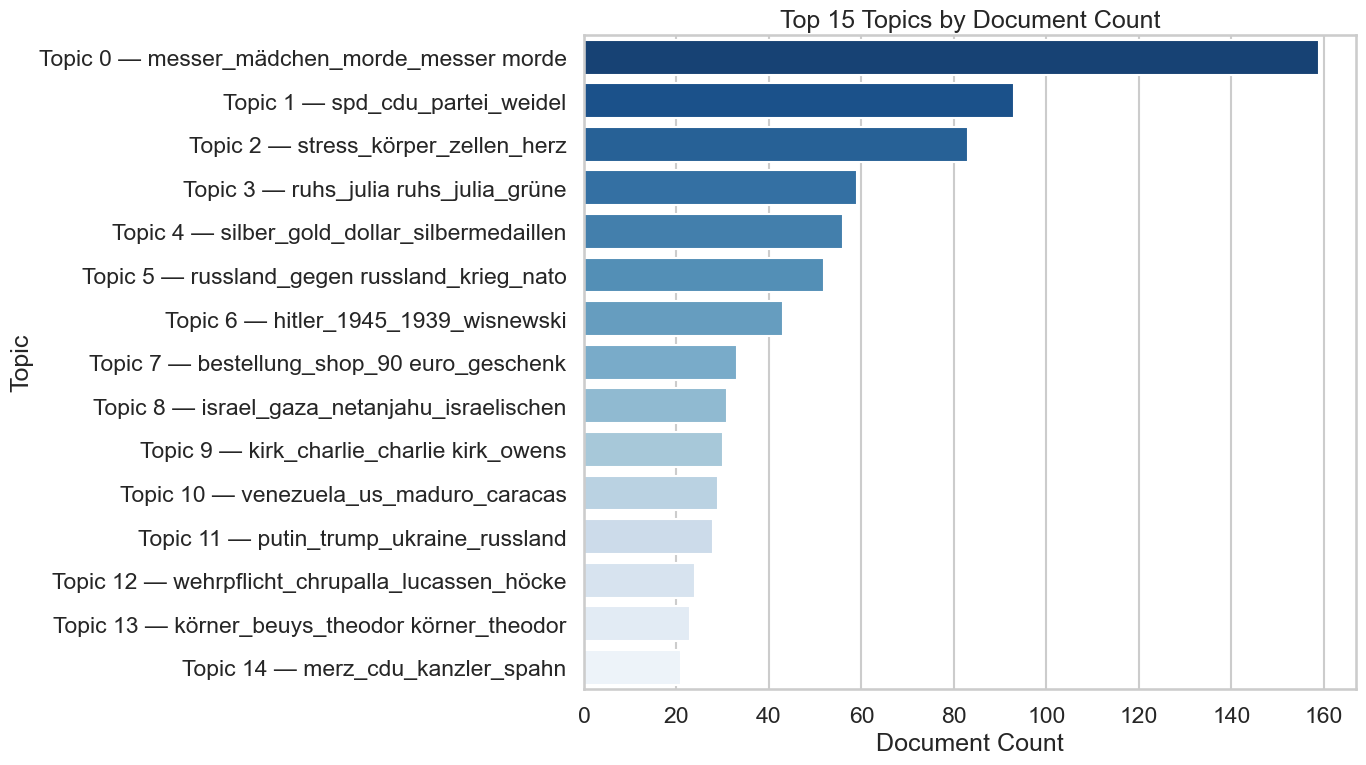

In [33]:
# Bar chart: first 15 non-outlier topics from the run model (with topic names)
run_result = result if "result" in globals() else result_compact
topic_info_run = run_result["topic_info"].copy()

top15_topics = topic_info_run.loc[topic_info_run["Topic"] != -1].head(15).copy()

# Clean topic name (remove leading "<topic_id>_")
top15_topics["TopicName"] = top15_topics["Name"].str.replace(r"^\d+_", "", regex=True)

# Combine topic id + readable name for y-axis
top15_topics["TopicLabel"] = (
    "Topic " + top15_topics["Topic"].astype(str) + " — " + top15_topics["TopicName"]
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(
    data=top15_topics,
    x="Count",
    y="TopicLabel",
    palette="Blues_r",
    ax=ax
)

ax.set_title("Top 15 Topics by Document Count")
ax.set_xlabel("Document Count")
ax.set_ylabel("Topic")
plt.tight_layout()
plt.show()